# Task 3, Transfer Learning

Duarte Ferreira 75419, Tiago Figueiredo 73187

Reproduces `bag_v9_kfold4` (Kaggle 0.48788): a 50/50 bag of one ConvNeXt-Tiny
trained on a single 80/20 split plus four more trained on 4 stratified folds.
Five models total. Runs in about 2.5h on a Kaggle T4.

The bag works because v9 and the k-fold models see different training data,
so their mistakes don't line up. Averaging their softmax outputs cancels some
of the noise. That's the whole trick.


## Setup

In [ ]:
import os, sys, json, copy, random, shutil, time, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny

print('torch:', torch.__version__, '  cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu :', torch.cuda.get_device_name(0))

torch: 2.8.0+cu126   cuda: True
gpu : NVIDIA GeForce RTX 3060 Laptop GPU


In [48]:
SEED = 42
IMG_SIZE = 384
BATCH_SIZE = 16
NUM_WORKERS = 0

LR_HEAD, WD_HEAD = 1e-3, 1e-4
HEAD_EPOCHS, HEAD_PATIENCE = 10, 5

LR_FINE, WD_FINE = 2e-4, 5e-4
FINE_EPOCHS, FINE_PATIENCE = 25, 6

LABEL_SMOOTHING = 0.1
MIXUP_ALPHA = 0.3

N_SPLITS = 4
VAL_RATIO_V9 = 0.20

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [49]:
# local data: Assignment1/data/task3/{train,test,train_labels.csv}
NB_DIR = os.path.abspath(os.path.dirname('__file__') or os.getcwd())
ASSIGN_DIR = os.path.abspath(os.path.join(NB_DIR, '..'))
BASE_DIR = os.path.join(ASSIGN_DIR, 'data', 'task3')

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')
LABELS_CSV = os.path.join(BASE_DIR, 'train_labels.csv')

assert os.path.isdir(TRAIN_DIR), f'train folder not found at {TRAIN_DIR}'
assert os.path.isfile(LABELS_CSV), f'labels csv not found at {LABELS_CSV}'

OUT_DIR = os.path.abspath('./runs')
os.makedirs(OUT_DIR, exist_ok=True)

V9_DIR = os.path.join(OUT_DIR, 'v9')
KFOLD_DIR = os.path.join(OUT_DIR, f'v9_kfold{N_SPLITS}')
BAG_DIR = os.path.join(OUT_DIR, 'bag_v9_kfold')
for d in [V9_DIR, KFOLD_DIR, BAG_DIR]:
    os.makedirs(d, exist_ok=True)

print('Base :', BASE_DIR)
print('Out  :', OUT_DIR)

Base : c:\Projects\DeepLearning\Assignment1\data\task3
Out  : c:\Projects\DeepLearning\Assignment1\notebooks\runs


## Data

1,194 images across 9 classes, pretty unbalanced (Water 252 vs Fighting 60).


In [50]:
df_all = pd.read_csv(LABELS_CSV)
le = LabelEncoder()
df_all['label_idx'] = le.fit_transform(df_all['label'])
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = le.classes_.tolist()

print(f'samples : {len(df_all)}')
print(f'classes : {CLASS_NAMES}')
print()
print(df_all['label'].value_counts().to_string())

samples : 1194
classes : ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']

label
Water       252
Normal      222
Grass       159
Bug         150
Fire        114
Rock         99
Ground       72
Poison       66
Fighting     60


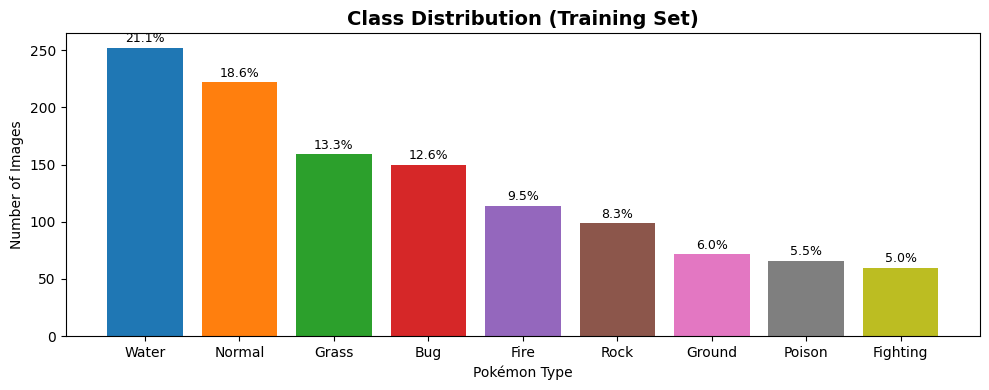

          count   pct
label                
Water       252  21.1
Normal      222  18.6
Grass       159  13.3
Bug         150  12.6
Fire        114   9.5
Rock         99   8.3
Ground       72   6.0
Poison       66   5.5
Fighting     60   5.0

Max/min imbalance ratio: 4.2x


In [51]:
counts = df_all["label"].value_counts().sort_values(ascending=False)
pct    = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(counts.index, counts.values, color=plt.cm.tab10.colors)
ax.set_title("Class Distribution (Training Set)", fontsize=14, fontweight="bold")
ax.set_xlabel("Pokémon Type")
ax.set_ylabel("Number of Images")
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2, f"{p}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "class_distribution.png"), dpi=150)
plt.show()

dist_df = pd.DataFrame({"count": counts, "pct": pct})
print(dist_df.to_string())

imbalance_ratio = counts.max() / counts.min()
print(f"\nMax/min imbalance ratio: {imbalance_ratio:.1f}x")

## Dataset + transforms

Two datasets (train/val and test). Three transforms: a light one for phase 1,
a heavy one for phase 2, and a deterministic one for val and TTA.


In [52]:
class PokemonDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, str(row['Id']) + '.png')).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, int(row['label_idx'])

class PokemonTestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.files = sorted(os.listdir(test_dir))
        self.test_dir = test_dir
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(os.path.join(self.test_dir, fname)).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, os.path.splitext(fname)[0]

In [53]:
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

# light aug while the backbone is frozen (phase 1)
head_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=5),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

# heavier aug once we start fine-tuning the top blocks (phase 2)
finetune_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

# deterministic: used for eval and as one of the two TTA views
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

## Model

ConvNeXt-Tiny with ImageNet weights, classifier head swapped for `Dropout(0.4)` +
`Linear(in, 9)`.

Two phases: train just the new head first, then unfreeze the top six feature blocks
and keep going at a lower LR. Freezing first stops the untrained head from blowing
up the pretrained weights with bad gradients.


In [54]:
def build_model(num_classes):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model

def freeze_backbone(model):
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith('classifier')

def unfreeze_top_blocks(model):
    # features 2..7 are the last six ConvNeXt stages. features.0, features.1 stay frozen.
    top_idx = {'2', '3', '4', '5', '6', '7'}
    for name, p in model.named_parameters():
        is_top  = name.startswith('features.') and name.split('.')[1] in top_idx
        is_head = name.startswith('classifier')
        p.requires_grad = is_top or is_head

def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

## Training loop

`run_phase` is reused for both phases of every model trained here. It tracks the
best macro-F1 on val, early-stops if it stops improving, and clips gradients so
mixup can't blow up a step. Mixup is only on during phase 2.


In [55]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(X)
            total_loss += criterion(logits, y).item() * len(y)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
    return total_loss / len(loader.dataset), f1_score(labels, preds, average='macro', zero_division=0)

def mixup_data(x, y, alpha=0.3):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam * crit(pred, ya) + (1 - lam) * crit(pred, yb)

def run_phase(model, train_loader, val_loader, criterion, optimizer, scheduler,
              epochs, patience, phase_name, ckpt_path, device, mixup_alpha=0.0):
    best_f1, best_weights, no_improve = -1.0, None, 0
    print(f'  {phase_name}  trainable={count_trainable(model):,}')
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            if mixup_alpha > 0:
                X, ya, yb, lam = mixup_data(X, y, mixup_alpha)
                optimizer.zero_grad()
                loss = mixup_criterion(criterion, model(X), ya, yb, lam)
            else:
                optimizer.zero_grad()
                loss = criterion(model(X), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * len(y)
        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_f1 = evaluate(model, val_loader, criterion, device)
        if scheduler is not None: scheduler.step()
        if val_f1 > best_f1:
            best_f1, no_improve = val_f1, 0
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, ckpt_path)
            marker = '  * best'
        else:
            no_improve += 1
            marker = f'  ({no_improve}/{patience})'
        print(f'    ep {epoch:3d}  train={train_loss:.4f}  val={val_loss:.4f}  f1={val_f1:.4f}{marker}', flush=True)
        if no_improve >= patience:
            print(f'    stopped early at epoch {epoch}')
            break
    model.load_state_dict(best_weights)
    return best_f1

In [56]:
def make_class_weights(train_df, num_classes, device):
    # sqrt-dampened inverse frequency. Raw inverse-freq was too aggressive
    # and hurt convergence; sqrt softens it enough to still help minority classes.
    counts = np.bincount(train_df['label_idx'], minlength=num_classes)
    w = np.array([1.0 / np.sqrt(max(int(counts[i]), 1)) for i in range(num_classes)], dtype=np.float32)
    w = w / w.sum() * num_classes
    return torch.tensor(w, dtype=torch.float32, device=device)

def train_one_model(train_df, val_df, ckpt_prefix):
    # Train both phases on one split and return the best-val model.
    train_dataset = PokemonDataset(train_df, TRAIN_DIR, transform=head_transform)
    val_dataset   = PokemonDataset(val_df,   TRAIN_DIR, transform=val_transform)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    criterion = nn.CrossEntropyLoss(
        weight=make_class_weights(train_df, NUM_CLASSES, DEVICE),
        label_smoothing=LABEL_SMOOTHING,
    )

    model = build_model(NUM_CLASSES).to(DEVICE)

    # phase 1
    freeze_backbone(model)
    opt_h = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR_HEAD, weight_decay=WD_HEAD)
    sch_h = optim.lr_scheduler.CosineAnnealingLR(opt_h, T_max=HEAD_EPOCHS, eta_min=1e-5)
    CKPT_P1 = f'{ckpt_prefix}_phase1.pth'
    best_p1 = run_phase(model, train_loader, val_loader, criterion, opt_h, sch_h,
                        HEAD_EPOCHS, HEAD_PATIENCE, 'phase 1 (head only)',
                        CKPT_P1, DEVICE, mixup_alpha=0.0)

    # phase 2
    unfreeze_top_blocks(model)
    train_dataset.transform = finetune_transform
    opt_f = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR_FINE, weight_decay=WD_FINE)
    sch_f = optim.lr_scheduler.CosineAnnealingLR(opt_f, T_max=FINE_EPOCHS, eta_min=1e-6)
    CKPT_P2 = f'{ckpt_prefix}_phase2.pth'
    best_p2 = run_phase(model, train_loader, val_loader, criterion, opt_f, sch_f,
                        FINE_EPOCHS, FINE_PATIENCE, 'phase 2 (fine-tune)',
                        CKPT_P2, DEVICE, mixup_alpha=MIXUP_ALPHA)

    # pick whichever phase scored higher on val
    best_src = CKPT_P2 if best_p2 >= best_p1 else CKPT_P1
    best_ckpt = f'{ckpt_prefix}_best.pth'
    shutil.copy(best_src, best_ckpt)
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))

    val_dataset.transform = val_transform
    return model, val_loader, float(max(best_p1, best_p2))

In [57]:
def tta_predict(model, dataset, batch_size=BATCH_SIZE):
    # 2-view TTA: original + hflip, averaged.
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    model.eval()
    softmax = nn.Softmax(dim=1)
    v1, v2, ids = [], [], []
    with torch.no_grad():
        for X, batch_ids in loader:
            X = X.to(DEVICE)
            v1.append(softmax(model(X)).cpu())
            v2.append(softmax(model(torch.flip(X, dims=[-1]))).cpu())
            if isinstance(batch_ids, torch.Tensor):
                ids.extend(batch_ids.numpy().tolist())
            else:
                ids.extend(list(batch_ids))
    return ((torch.cat(v1) + torch.cat(v2)) / 2).numpy(), ids

def tta_predict_val(model, val_df):
    # Same TTA as tta_predict but on a labelled DataFrame, so we also return y.
    ds = PokemonDataset(val_df, TRAIN_DIR, transform=val_transform)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model.eval()
    softmax = nn.Softmax(dim=1)
    v1, v2, ys = [], [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            v1.append(softmax(model(X)).cpu())
            v2.append(softmax(model(torch.flip(X, dims=[-1]))).cpu())
            ys.append(y.numpy())
    probs = ((torch.cat(v1) + torch.cat(v2)) / 2).numpy()
    return probs, val_df['Id'].values.tolist(), np.concatenate(ys)

## Stage A: v9 single split

Stratified 80/20, seed 42 (Kaggle 0.48782). About 25 min


In [58]:
train_df_v9, val_df_v9 = train_test_split(
    df_all, test_size=VAL_RATIO_V9, stratify=df_all['label_idx'], random_state=SEED,
)
train_df_v9 = train_df_v9.reset_index(drop=True)
val_df_v9   = val_df_v9.reset_index(drop=True)
print(f'stage A: train={len(train_df_v9)}  val={len(val_df_v9)}')

t0 = time.time()
model_v9, val_loader_v9, v9_val_f1 = train_one_model(
    train_df_v9, val_df_v9, ckpt_prefix=os.path.join(V9_DIR, 'v9'),
)
print(f'\nv9 best val macro-F1: {v9_val_f1:.4f}  ({(time.time()-t0)/60:.1f} min)')

stage A: train=955  val=239
  phase 1 (head only)  trainable=8,457
    ep   1  train=2.2610  val=2.2453  f1=0.1151  * best
    ep   2  train=2.1420  val=2.2399  f1=0.1506  * best
    ep   3  train=2.0666  val=2.2617  f1=0.1187  (1/5)
    ep   4  train=2.0308  val=2.2622  f1=0.1534  * best
    ep   5  train=1.9840  val=2.2598  f1=0.1754  * best
    ep   6  train=1.9391  val=2.2649  f1=0.1857  * best
    ep   7  train=1.9119  val=2.2663  f1=0.1772  (1/5)
    ep   8  train=1.8970  val=2.2708  f1=0.1637  (2/5)
    ep   9  train=1.8830  val=2.2707  f1=0.1763  (3/5)
    ep  10  train=1.8790  val=2.2714  f1=0.1727  (4/5)
  phase 2 (fine-tune)  trainable=27,584,265
    ep   1  train=2.1019  val=1.9925  f1=0.2903  * best
    ep   2  train=1.7086  val=1.8493  f1=0.4043  * best
    ep   3  train=1.4721  val=1.7435  f1=0.3836  (1/6)
    ep   4  train=1.1813  val=1.5386  f1=0.5577  * best
    ep   5  train=1.1938  val=1.5113  f1=0.5311  (1/6)
    ep   6  train=1.0661  val=1.4583  f1=0.5404  (2/6)
 

In [ ]:
# test predictions for v9
test_dataset = PokemonTestDataset(TEST_DIR, transform=val_transform)
v9_test_probs, test_ids = tta_predict(model_v9, test_dataset)
np.save(os.path.join(V9_DIR, 'test_probs.npy'), v9_test_probs)
with open(os.path.join(V9_DIR, 'test_ids.json'), 'w') as f:
    json.dump(test_ids, f)
print(f'v9 test_probs: {v9_test_probs.shape}  n_ids: {len(test_ids)}')

# free the GPU
del model_v9
torch.cuda.empty_cache()

v9 test_probs: (300, 9)  n_ids: 300


## Stage B: 4-fold retrain

Same recipe but 4 times, each on a different 75/25 stratified split. Stitching the
held-out predictions gives an OOF macro-F1 across all 1,194 samples, which turns out to be a better predictor than the 239-sample single split from Stage A.
About 80 min (20 per fold).


In [61]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results = []

t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(skf.split(df_all, df_all['label_idx'])):
    train_df_k = df_all.iloc[tr_idx].reset_index(drop=True)
    val_df_k   = df_all.iloc[va_idx].reset_index(drop=True)
    print(f'\nfold {fold+1}/{N_SPLITS}  train={len(train_df_k)}  val={len(val_df_k)}')

    fold_dir = os.path.join(KFOLD_DIR, f'fold{fold}')
    os.makedirs(fold_dir, exist_ok=True)

    model_k, _, best_val = train_one_model(
        train_df_k, val_df_k, ckpt_prefix=os.path.join(fold_dir, 'fold'),
    )

    val_probs, val_ids, val_labels = tta_predict_val(model_k, val_df_k)
    val_f1_tta = f1_score(val_labels, val_probs.argmax(1), average='macro', zero_division=0)
    print(f'  fold {fold} val f1 (2-view TTA): {val_f1_tta:.4f}')

    test_probs, tids = tta_predict(model_k, test_dataset)
    assert tids == test_ids, 'test_ids mismatch between folds'

    fold_results.append({
        'fold': fold,
        'best_val': float(best_val),
        'val_f1_tta': float(val_f1_tta),
        'val_ids': val_ids,
        'val_probs': val_probs,
        'val_labels': val_labels,
        'test_probs': test_probs,
    })

    del model_k
    torch.cuda.empty_cache()

print(f'\nk-fold total: {(time.time()-t0)/60:.1f} min')


fold 1/4  train=895  val=299
  phase 1 (head only)  trainable=8,457
    ep   1  train=2.2742  val=2.2601  f1=0.0906  * best
    ep   2  train=2.1519  val=2.2616  f1=0.1078  * best
    ep   3  train=2.0963  val=2.2598  f1=0.0978  (1/5)
    ep   4  train=2.0212  val=2.2624  f1=0.0970  (2/5)
    ep   5  train=1.9879  val=2.2717  f1=0.1008  (3/5)
    ep   6  train=1.9550  val=2.2789  f1=0.1080  * best
    ep   7  train=1.9240  val=2.2807  f1=0.1060  (1/5)
    ep   8  train=1.9086  val=2.2817  f1=0.1033  (2/5)
    ep   9  train=1.8983  val=2.2811  f1=0.1022  (3/5)
    ep  10  train=1.8739  val=2.2814  f1=0.1021  (4/5)
  phase 2 (fine-tune)  trainable=27,584,265
    ep   1  train=2.1492  val=2.1061  f1=0.2341  * best
    ep   2  train=1.7446  val=1.8828  f1=0.3326  * best
    ep   3  train=1.4498  val=1.7978  f1=0.4111  * best
    ep   4  train=1.2660  val=1.6462  f1=0.4804  * best
    ep   5  train=1.2093  val=1.5906  f1=0.5590  * best
    ep   6  train=1.0861  val=1.6094  f1=0.5214  (1/6)

In [62]:
# turn the per-fold val predictions into one OOF array and score it against all val labels
id_to_probs = {}
for r in fold_results:
    for _id, prob in zip(r['val_ids'], r['val_probs']):
        id_to_probs[_id] = prob
oof_probs  = np.stack([id_to_probs[_id] for _id in df_all['Id'].values])
oof_labels = df_all['label_idx'].values
oof_preds  = oof_probs.argmax(1)
oof_f1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)

# mean the per-fold test softmaxes
kfold_test_probs = np.stack([r['test_probs'] for r in fold_results]).mean(0)
np.save(os.path.join(KFOLD_DIR, 'test_probs.npy'), kfold_test_probs)
np.save(os.path.join(KFOLD_DIR, 'oof_probs.npy'), oof_probs)
np.save(os.path.join(KFOLD_DIR, 'oof_labels.npy'), oof_labels)

for r in fold_results:
    print(f'  fold {r["fold"]}  val_f1_tta = {r["val_f1_tta"]:.4f}')
mean_val = float(np.mean([r['val_f1_tta'] for r in fold_results]))
std_val  = float(np.std ([r['val_f1_tta'] for r in fold_results]))
print(f'  mean        = {mean_val:.4f} +/- {std_val:.4f}')
print(f'\nOOF macro-F1 (1,194 stitched samples): {oof_f1:.4f}')
print(f'v9 single-split val (239 samples): {v9_val_f1:.4f}')

  fold 0  val_f1_tta = 0.7692
  fold 1  val_f1_tta = 0.7065
  fold 2  val_f1_tta = 0.8329
  fold 3  val_f1_tta = 0.7700
  mean        = 0.7697 +/- 0.0447

OOF macro-F1 (1,194 stitched samples): 0.7702
v9 single-split val (239 samples): 0.8181


Average the v9 and k-fold test softmaxes 50/50, argmax, write the CSV


In [63]:
bag_probs = 0.5 * v9_test_probs + 0.5 * kfold_test_probs
bag_preds = bag_probs.argmax(1)
bag_labels = le.inverse_transform(bag_preds)

submission = pd.DataFrame({'Id': test_ids, 'label': bag_labels})
SUB_PATH = os.path.join(BAG_DIR, 'submission.csv')
submission.to_csv(SUB_PATH, index=False)

# save the inputs
np.save(os.path.join(BAG_DIR, 'test_probs.npy'), bag_probs)
with open(os.path.join(BAG_DIR, 'test_ids.json'), 'w') as f:
    json.dump(test_ids, f)
with open(os.path.join(BAG_DIR, 'summary.json'), 'w') as f:
    json.dump({
        'bag_name': 'bag_v9_kfold4',
        'weights': {'v9': 0.5, 'kfold4': 0.5},
        'components': ['v9', f'kfold{N_SPLITS}'],
        'v9_val_f1': float(v9_val_f1),
        'kfold_oof_f1': float(oof_f1),
        'per_fold_f1': [r['val_f1_tta'] for r in fold_results],
        'n_test': len(test_ids),
    }, f, indent=2)

print(f'submission: {SUB_PATH}')
print(submission['label'].value_counts().to_string())

submission: c:\Projects\DeepLearning\Assignment1\notebooks\runs\bag_v9_kfold\submission.csv
label
Normal      94
Water       58
Grass       54
Bug         25
Fire        24
Fighting    15
Poison      11
Rock        11
Ground       8


## Results

In [64]:
print(classification_report(oof_labels, oof_preds, target_names=CLASS_NAMES, digits=3, zero_division=0))

              precision    recall  f1-score   support

         Bug      0.877     0.760     0.814       150
    Fighting      0.714     0.667     0.690        60
        Fire      0.815     0.851     0.833       114
       Grass      0.793     0.918     0.851       159
      Ground      0.784     0.556     0.650        72
      Normal      0.777     0.784     0.780       222
      Poison      0.757     0.803     0.779        66
        Rock      0.779     0.677     0.724        99
       Water      0.777     0.845     0.810       252

    accuracy                          0.791      1194
   macro avg      0.786     0.762     0.770      1194
weighted avg      0.792     0.791     0.788      1194



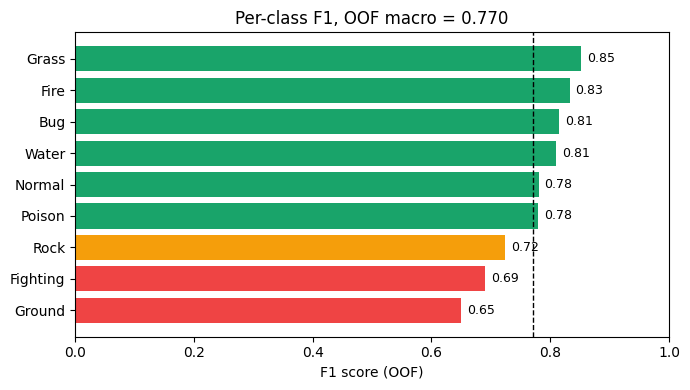

In [65]:
rep = classification_report(oof_labels, oof_preds, target_names=CLASS_NAMES,
                            output_dict=True, zero_division=0)
class_f1 = np.array([rep[c]['f1-score'] for c in CLASS_NAMES])
order = np.argsort(class_f1)
GREEN, AMBER, RED = '#19A46A', '#F59E0B', '#EF4444'
colors = [GREEN if class_f1[i] >= 0.76 else (AMBER if class_f1[i] >= 0.70 else RED) for i in order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([CLASS_NAMES[i] for i in order], [class_f1[i] for i in order], color=colors)
for i, idx in enumerate(order):
    ax.text(class_f1[idx] + 0.01, i, f'{class_f1[idx]:.2f}', va='center', fontsize=9)
ax.set_xlim(0, 1.0)
ax.set_xlabel('F1 score (OOF)')
ax.axvline(rep['macro avg']['f1-score'], color='black', linestyle='--', linewidth=1)
ax.set_title(f'Per-class F1, OOF macro = {rep["macro avg"]["f1-score"]:.3f}')
plt.tight_layout(); plt.show()

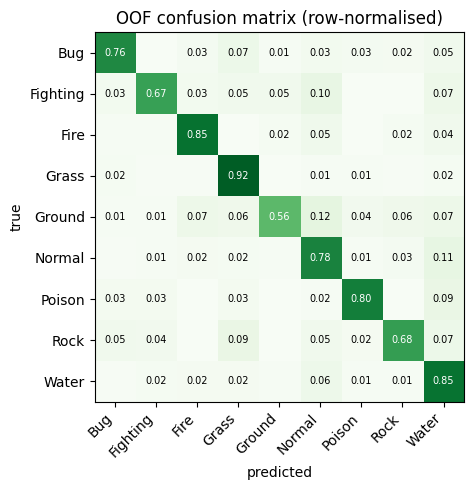

In [66]:
cm = confusion_matrix(oof_labels, oof_preds, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('OOF confusion matrix (row-normalised)')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        v = cm[i, j]
        if v > 0.01:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if v > 0.5 else 'black')
plt.tight_layout(); plt.show()

## Conclusion

The 0.82 val number from Stage A was mostly luck. A 239-sample stratified split is
too small to measure macro-F1 across 9 classes. The k-fold OOF of 0.76 turned out
to be a much tighter fit to what Kaggle actually gave us.

On its own, the k-fold bag is worse than v9 because each fold trains on less data.
But because they saw different splits, their errors don't line up, and the 50/50
mix beats both components. The arithmetic mean of the two Kaggle scores is
(0.488 + 0.441) / 2 = 0.465; the bag scored 0.488. That +0.024 is the decorrelation benefit.

Rock and Ground still lose on F1. Both have few training samples,
earthy colours, and similar silhouettes against the real backgrounds. That's a data problem, not a model problem.
